In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

In [56]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [57]:
df.shape

(7043, 21)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [59]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [62]:
df['gender']=df['gender'].str.lower()

In [63]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [64]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [65]:
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [66]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [68]:
df=df.dropna(subset=['TotalCharges'])

In [69]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [70]:
num_cols= df.select_dtypes(include='number').columns
num_cols= num_cols.drop('SeniorCitizen')
num_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [71]:
cat_cols= df.select_dtypes(include='object').columns.to_list()
cat_cols=cat_cols + ['SeniorCitizen']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [72]:
cat_cols = [col for col in cat_cols if col not in [ 'Churn','customerID']]

In [73]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [74]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


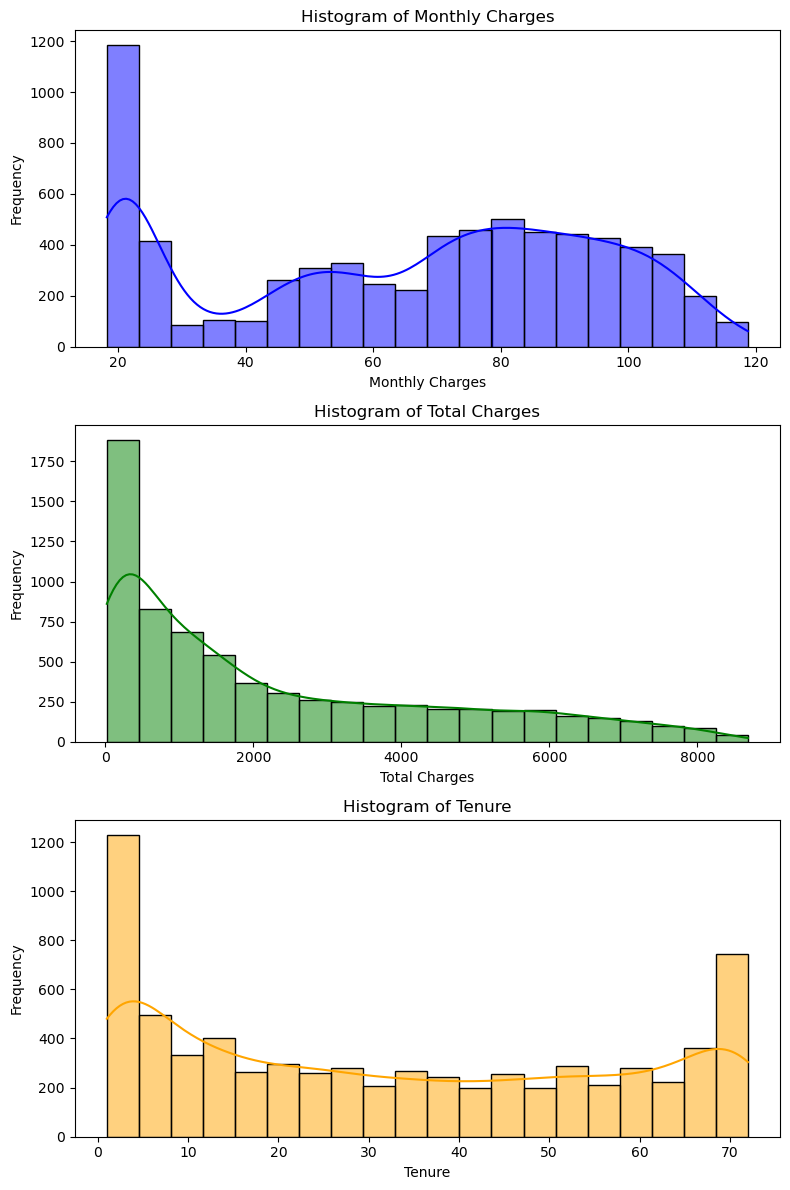

In [75]:

fig, axes = plt.subplots(3,1, figsize=(8,12))

sns.histplot(data=df['MonthlyCharges'], bins=20, kde=True, color='blue', ax=axes[0])
axes[0].set_title("Histogram of Monthly Charges")
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Frequency")

sns.histplot(data=df['TotalCharges'], bins=20,kde=True, color='green', ax=axes[1])
axes[1].set_title("Histogram of Total Charges")
axes[1].set_xlabel("Total Charges")
axes[1].set_ylabel("Frequency")

sns.histplot(data=df['tenure'], bins=20, kde=True, color='orange', ax=axes[2])
axes[2].set_title("Histogram of Tenure")
axes[2].set_xlabel("Tenure")
axes[2].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [76]:
df['gender'].value_counts()

gender
male      3549
female    3483
Name: count, dtype: int64

In [77]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [78]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [79]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [80]:
df['TechSupport'].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

C:\Users\gbipi\AppData\Local\Temp\ipykernel_17472\1312108996.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90)


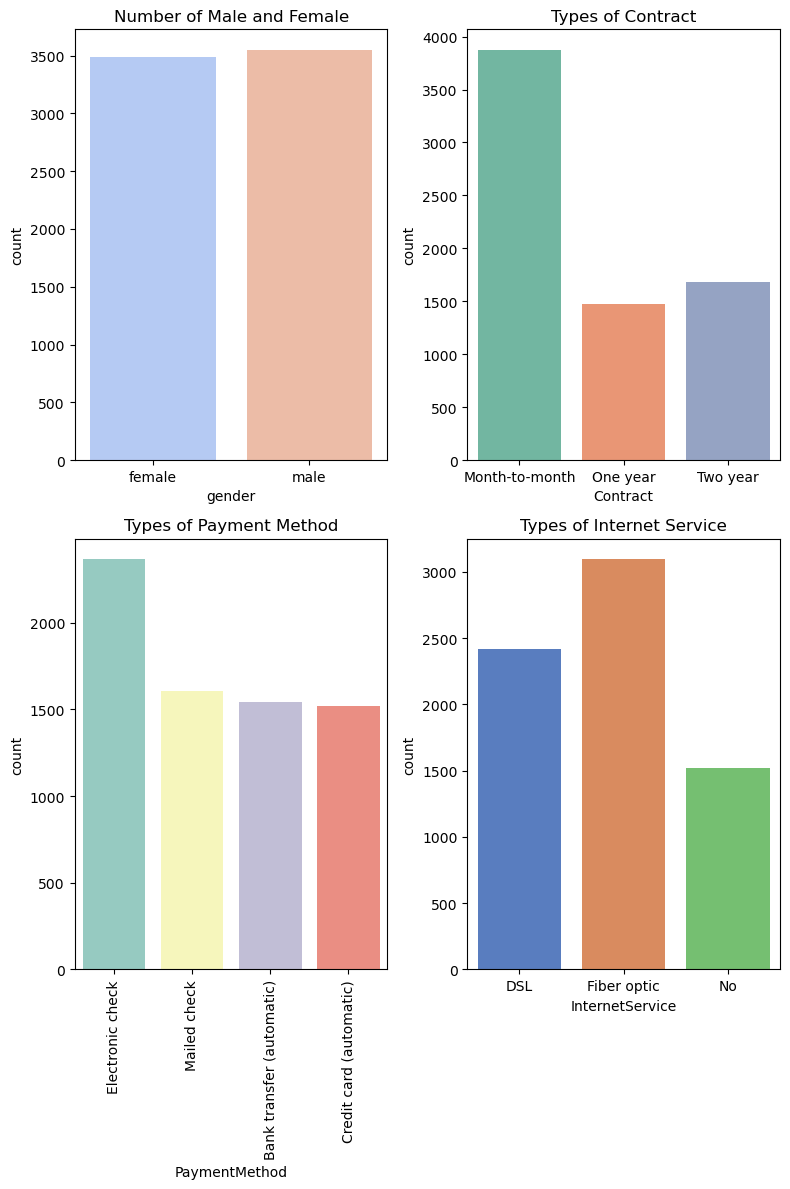

In [81]:
fig, axes= plt.subplots(2,2, figsize=(8,12))
axes= axes.ravel()
sns.countplot(x='gender', data=df, palette='coolwarm', hue='gender',ax=axes[0])
axes[0].set_title("Number of Male and Female")

sns.countplot(x='Contract', data=df, hue='Contract', palette='Set2', ax=axes[1])
axes[1].set_title("Types of Contract")

sns.countplot(x='PaymentMethod', data=df, hue='PaymentMethod', palette='Set3', ax=axes[2])
axes[2].set_title("Types of Payment Method")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90)

sns.countplot(x='InternetService', data=df, hue='InternetService', palette='muted', ax=axes[3])
axes[3].set_title("Types of Internet Service")

plt.tight_layout()
plt.show()


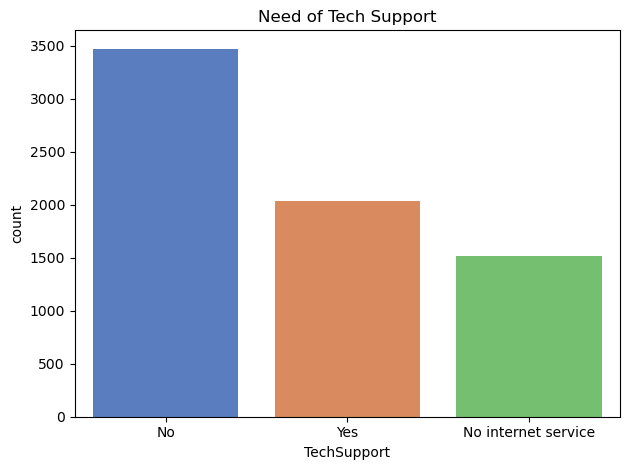

In [82]:
sns.countplot(x='TechSupport', data=df, hue='TechSupport', palette='muted')
plt.title('Need of Tech Support')

plt.tight_layout()
plt.show()

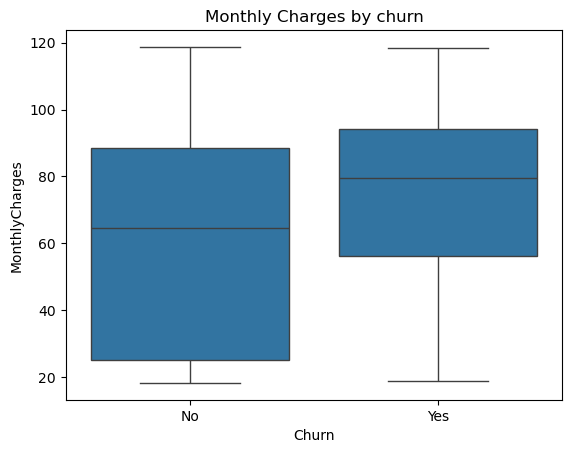

In [83]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by churn')
plt.show()

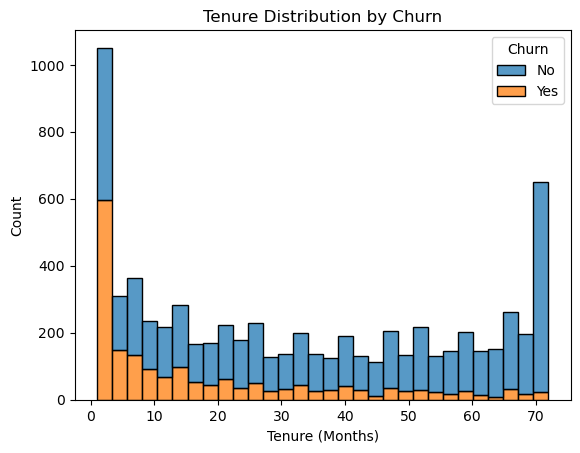

In [84]:

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

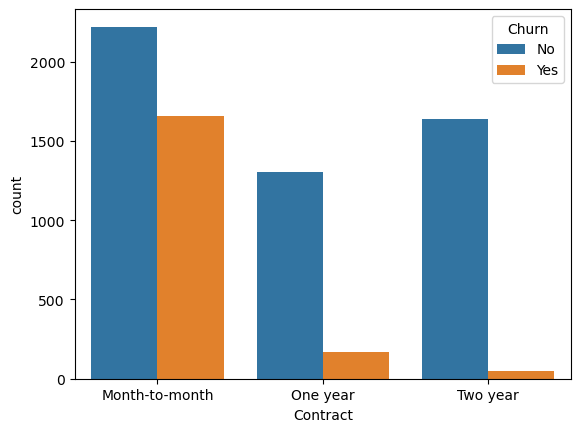

In [85]:
sns.countplot(data=df, x='Contract',  hue='Churn')
plt.show()

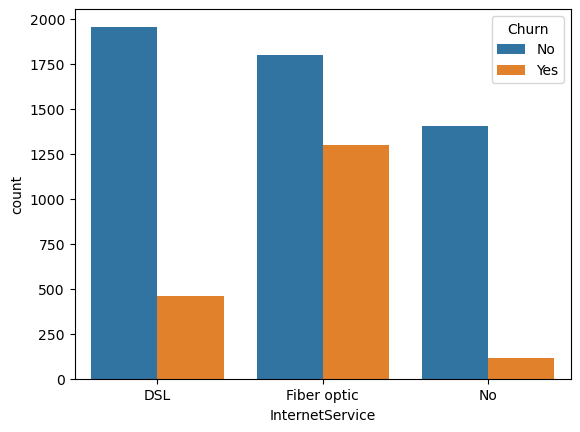

In [86]:
sns.countplot(data=df, x='InternetService',  hue='Churn')
plt.show()

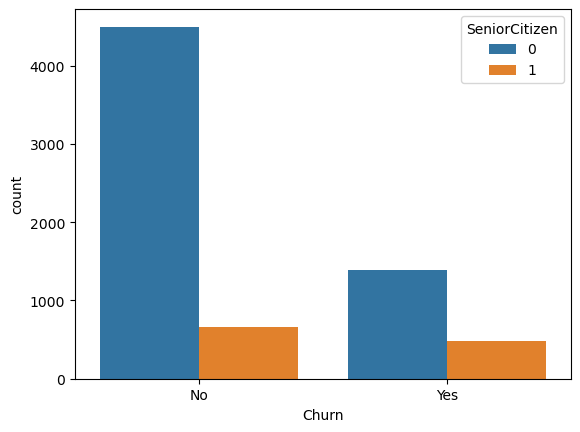

In [87]:
sns.countplot(x='Churn', hue='SeniorCitizen', data=df)
plt.show()

In [88]:
corr_matrix= df[num_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


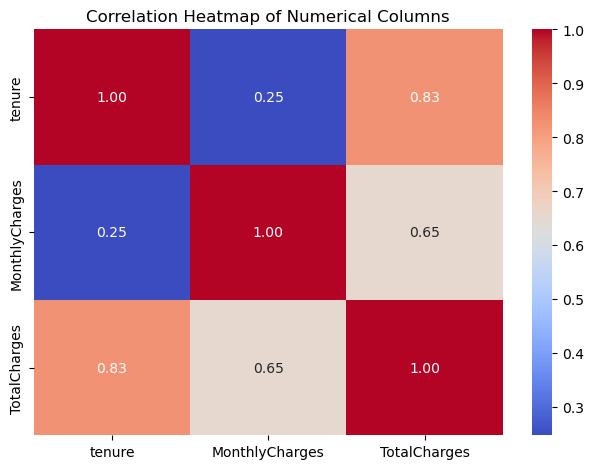

In [89]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Columns")
plt.tight_layout()
plt.show()

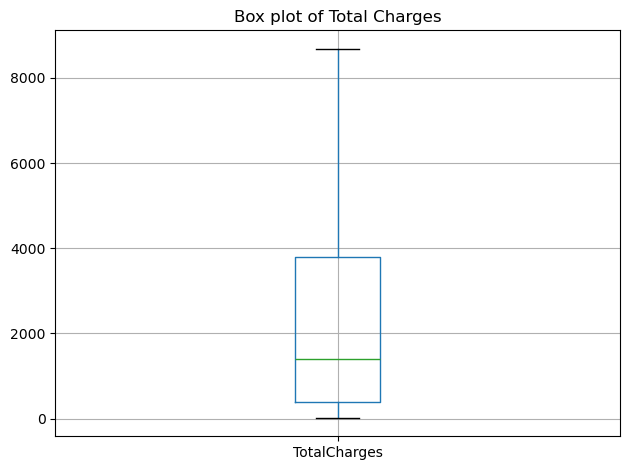

In [90]:
df.boxplot(column=["TotalCharges"])
plt.title("Box plot of Total Charges")
plt.tight_layout()
plt.show()

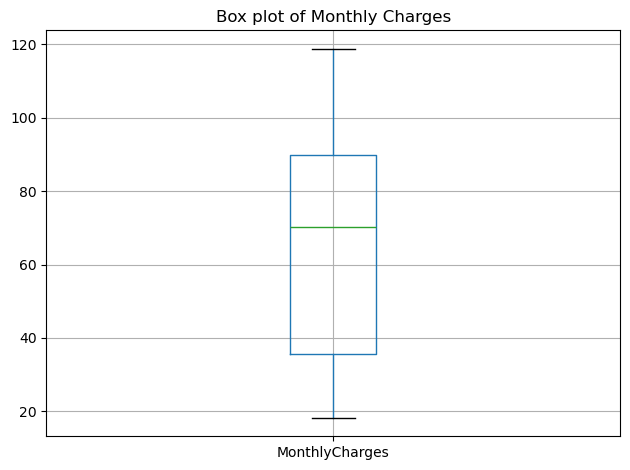

In [91]:
df.boxplot(column=['MonthlyCharges'])
plt.title("Box plot of Monthly Charges")
plt.tight_layout()
plt.show()

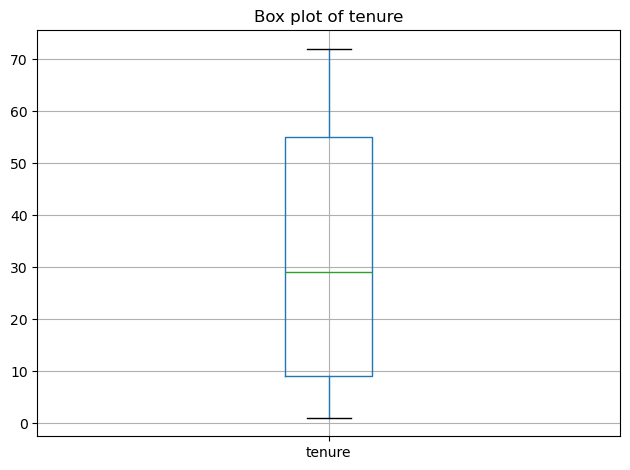

In [92]:
df.boxplot(column=["tenure"])
plt.title("Box plot of tenure")
plt.tight_layout()
plt.show()

In [93]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [94]:
def tenure_group(tenure):
    if tenure <=12:
        return 'New'
    elif tenure <=48:
        return 'Medium'
    else:
        return 'Long-term'
df['tenure_group']= df['tenure'].apply(tenure_group)

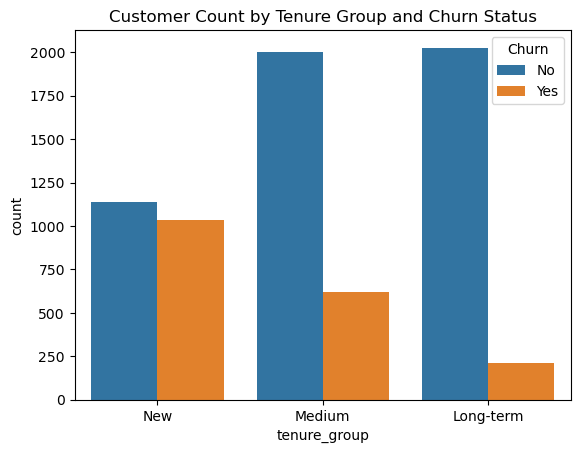

In [95]:
sns.countplot(x='tenure_group', data=df, hue='Churn')
plt.title('Customer Count by Tenure Group and Churn Status')
plt.show()

Hypotheses
1. Customers with higher monthly charges are more likely to churn.

2. Customers with month-to-month contracts churn more frequently than long-term customers.

3. Customers with longer tenure are less likely to churn.

Hypotheses testing

Null Hypothesis (H0) :
There is no significant difference in the average tenure between customers who churned and those who did not churn.

Alternative Hypothesis (H1) :
Customers who churn have a significantly lower average tenure compared to those who did not churn.

In [105]:
churn_yes= df[df['Churn'] == "Yes"] ["tenure"]
churn_no= df[df['Churn']=="No"]["tenure"]
stat, p_value= ttest_ind(churn_yes, churn_no, equal_var=False)
print("T-statistic:", stat)
print("p-value:", p_value)

T-statistic: -34.97187009750348
p-value: 2.3470747188949526e-234


In [97]:
X=df.drop('Churn', axis=1)
y=df['Churn'].map({'Yes':1, 'No':0})

In [98]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [99]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_group         object
dtype: object


In [100]:
preprocessor= ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols),
                  ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), cat_cols)])


In [101]:
pipeline= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [102]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [103]:
y_pred= pipeline.predict(X_test)

In [104]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.80
